## Homework 6

Second derivatives M:
[ 0.         -4.36363636  5.45454545 -5.45454545  4.36363636  0.        ]


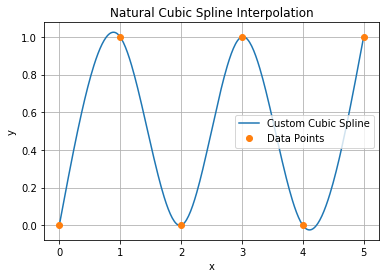

In [3]:
import numpy as np
import matplotlib.pyplot as plt


def setup_tridiagonal_matrix(x, y):
    """
    Build the tridiagonal system for a natural cubic spline.

    Returns:
        A = subdiagonal
        B = main diagonal
        C = superdiagonal
        D = right-hand side
    """
    n = len(x)
    h = np.diff(x)

    A = np.zeros(n - 2)
    B = np.zeros(n - 2)
    C = np.zeros(n - 2)
    D = np.zeros(n - 2)

    for i in range(1, n - 1):
        A[i - 1] = h[i - 1]
        B[i - 1] = 2 * (h[i - 1] + h[i])
        C[i - 1] = h[i]
        D[i - 1] = 6 * (((y[i + 1] - y[i]) / h[i]) - ((y[i] - y[i - 1]) / h[i - 1]))

    return A, B, C, D


def thomas_algorithm(a, b, c, d):
    """
    Solve a tridiagonal system using the Thomas algorithm.
    a: subdiagonal, length n-1
    b: main diagonal, length n
    c: superdiagonal, length n-1
    d: RHS, length n
    """
    a = a.astype(float).copy()
    b = b.astype(float).copy()
    c = c.astype(float).copy()
    d = d.astype(float).copy()

    n = len(b)

    # Forward elimination
    for i in range(1, n):
        w = a[i - 1] / b[i - 1]
        b[i] = b[i] - w * c[i - 1]
        d[i] = d[i] - w * d[i - 1]

    # Back substitution
    x = np.zeros(n)
    x[-1] = d[-1] / b[-1]

    for i in range(n - 2, -1, -1):
        x[i] = (d[i] - c[i] * x[i + 1]) / b[i]

    return x


def compute_second_derivatives(x, y):
    """
    Compute the spline second derivatives M.
    Natural boundary conditions: M[0] = M[-1] = 0
    """
    n = len(x)

    A, B, C, D = setup_tridiagonal_matrix(x, y)

    M_interior = thomas_algorithm(A[1:], B, C[:-1], D)

    M = np.zeros(n)
    M[1:-1] = M_interior

    return M


def evaluate_spline(x, y, M, x_eval):
    """
    Evaluate the natural cubic spline at x_eval.
    """
    i = np.searchsorted(x, x_eval) - 1

    # Clamp
    if i < 0:
        i = 0
    elif i >= len(x) - 1:
        i = len(x) - 2

    h = x[i + 1] - x[i]

    term1 = M[i] * (x[i + 1] - x_eval) ** 3 / (6 * h)
    term2 = M[i + 1] * (x_eval - x[i]) ** 3 / (6 * h)
    term3 = (y[i] - M[i] * h ** 2 / 6) * (x[i + 1] - x_eval) / h
    term4 = (y[i + 1] - M[i + 1] * h ** 2 / 6) * (x_eval - x[i]) / h

    return term1 + term2 + term3 + term4


x = np.array([0, 1, 2, 3, 4, 5], dtype=float)
y = np.array([0, 1, 0, 1, 0, 1], dtype=float)

M = compute_second_derivatives(x, y)

x_interp = np.linspace(0, 5, 300)
y_interp = np.array([evaluate_spline(x, y, M, val) for val in x_interp])

print("Second derivatives M:")
print(M)

plt.plot(x_interp, y_interp, label="Custom Cubic Spline")
plt.plot(x, y, "o", label="Data Points")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Natural Cubic Spline Interpolation")
plt.legend()
plt.grid(True)
plt.show()